# Exploratory Data Analysis of the US Arrests Dataset

**Author:** Nathan Kap

# Introduction

The US Arrests dataset contains crime statistics for all 50 U.S. states. The variables include murder, assault, rape, and the percentage of the population living in urban areas.

The purpose of this report is to explore the relationships between these variables, identify trends and outliers, and draw conclusions using statistical summaries and data visualizations.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

try:
    df = pd.read_csv("UsArrests.csv")
    print("Dataset loaded successfully.")
except FileNotFoundError:
    print("Error: UsArrests.csv not found.")

Dataset loaded successfully.


In [2]:
df.head()

,City,Murder,Assault,UrbanPop,Rape
0,Alabama,13.2,236,58,21.2
1,Alaska,10.0,263,48,44.5
2,Arizona,8.1,294,80,31.0
3,Arkansas,8.8,190,50,19.5
4,California,9.0,276,91,40.6


# Data Cleaning

The dataset was inspected to ensure that all columns were correctly imported, numerical values were stored using the correct data types, and duplicate observations were identified.

In [3]:
print(df.info())
print(df.describe())

print("\nDuplicate Rows:", df.duplicated().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   City      50 non-null     object 
 1   Murder    50 non-null     float64
 2   Assault   50 non-null     int64  
 3   UrbanPop  50 non-null     int64  
 4   Rape      50 non-null     float64
dtypes: float64(2), int64(2), object(1)
memory usage: 2.1+ KB
None
         Murder     Assault   UrbanPop       Rape
count  50.00000   50.000000  50.000000  50.000000
mean    7.78800  170.760000  65.540000  21.232000
std     4.35551   83.337661  14.474763   9.366385
min     0.80000   45.000000  32.000000   7.300000
25%     4.07500  109.000000  54.500000  15.075000
50%     7.25000  159.000000  66.000000  20.100000
75%    11.25000  249.000000  77.750000  26.175000
max    17.40000  337.000000  91.000000  46.000000

Duplicate Rows: 0


# Missing Data

The dataset was checked for missing values before performing any analysis.

In [4]:
print(df.isnull().sum())

City        0
Murder      0
Assault     0
UrbanPop    0
Rape        0
dtype: int64


No missing values were identified in the dataset. Therefore, no imputation or deletion of observations was required before analysis.

# Figure 1 - Distribution of Crime Rates

Histograms allow us to understand how each crime variable is distributed across the United States.

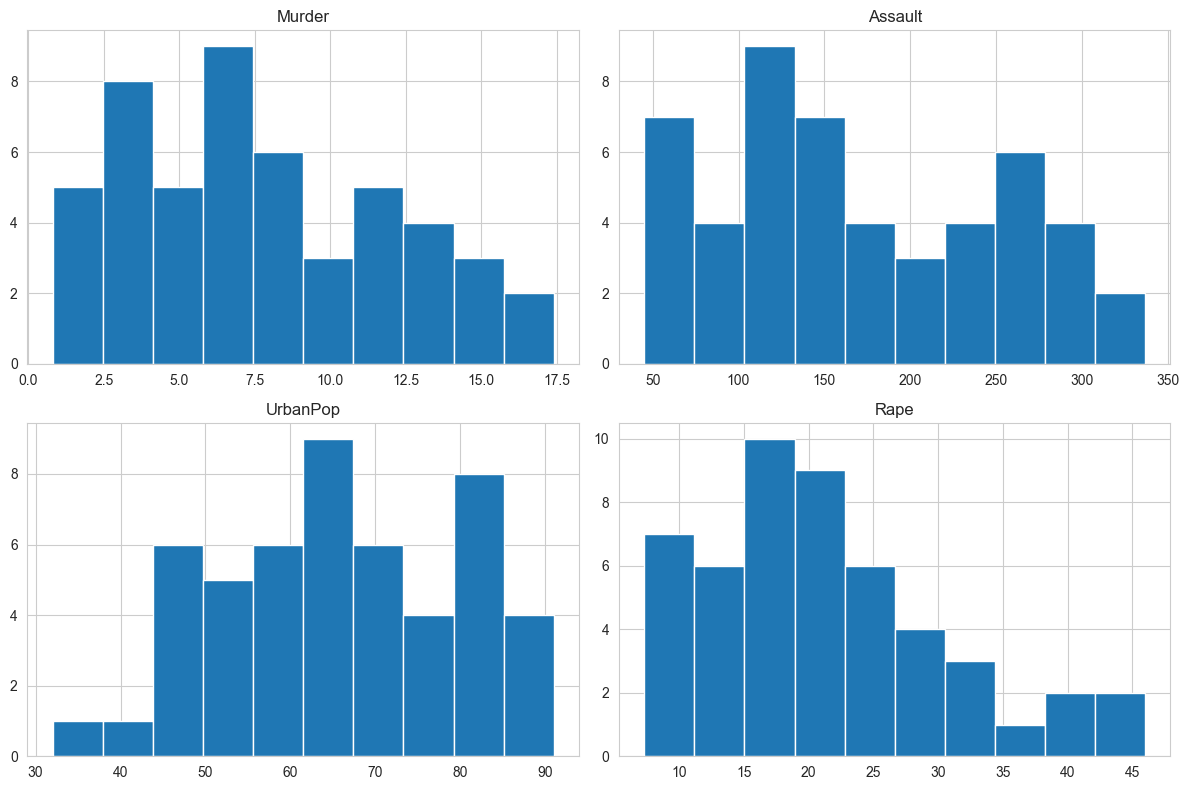

In [5]:
df.hist(figsize=(12,8))
plt.tight_layout()
plt.show()

# Figure 2 - Correlation Matrix

A correlation matrix helps identify relationships between the numerical variables.

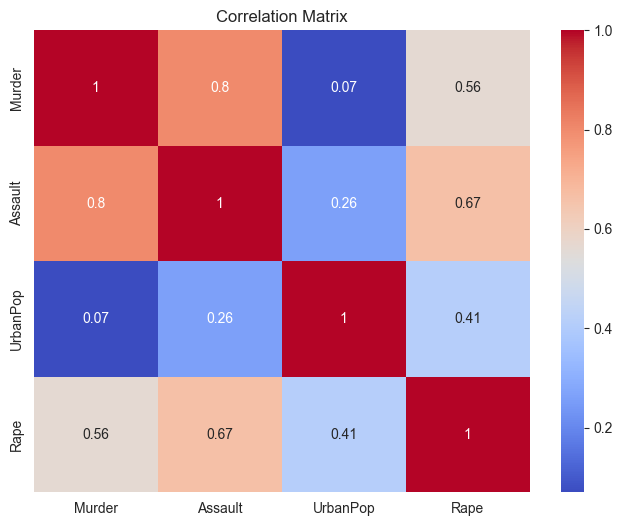

In [6]:
plt.figure(figsize=(8,6))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Matrix")
plt.show()

# Figure 3 - Murder versus Assault

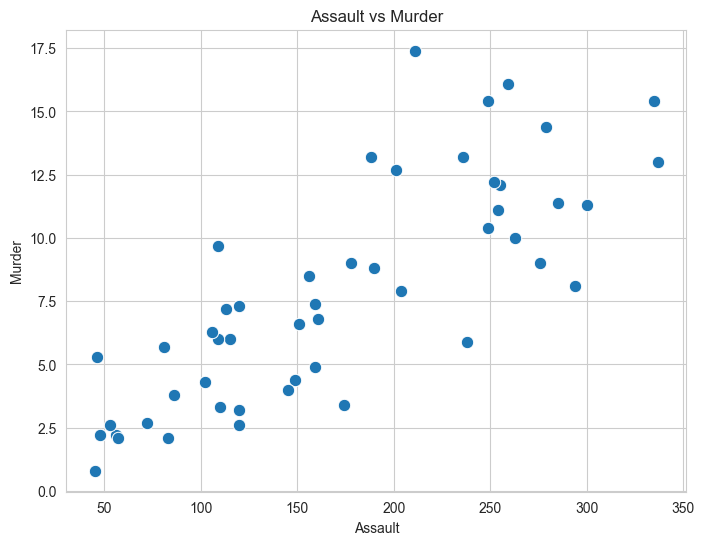

In [7]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x="Assault",
    y="Murder",
    s=80
)

plt.title("Assault vs Murder")

plt.show()

# Figure 4 - Urban Population versus Murder

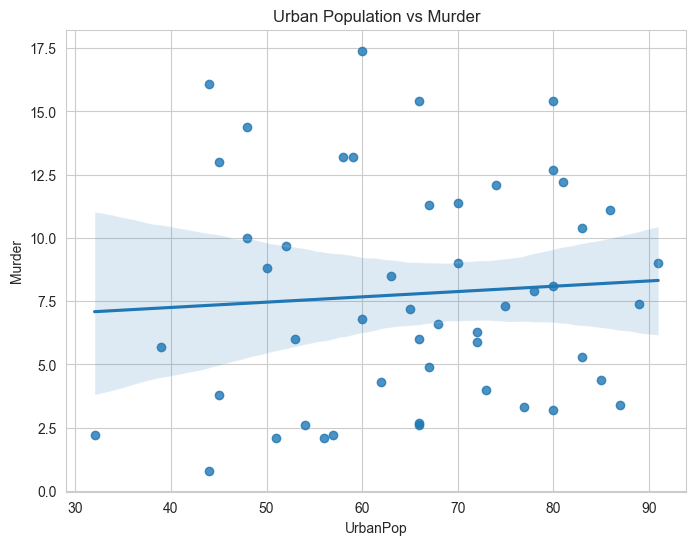

In [8]:
plt.figure(figsize=(8,6))

sns.regplot(
    data=df,
    x="UrbanPop",
    y="Murder"
)

plt.title("Urban Population vs Murder")

plt.show()

# Figure 5 - Boxplots

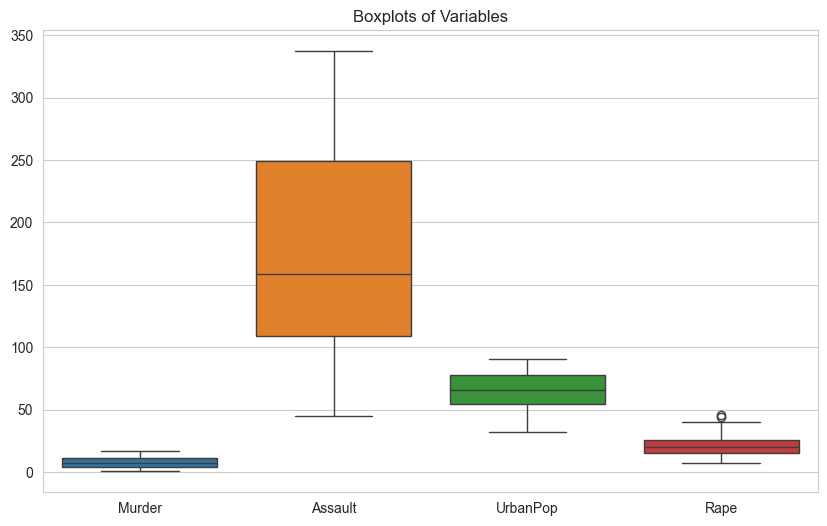

In [9]:
plt.figure(figsize=(10,6))

sns.boxplot(data=df)

plt.title("Boxplots of Variables")

plt.show()

# Figure 6 - Pairplot

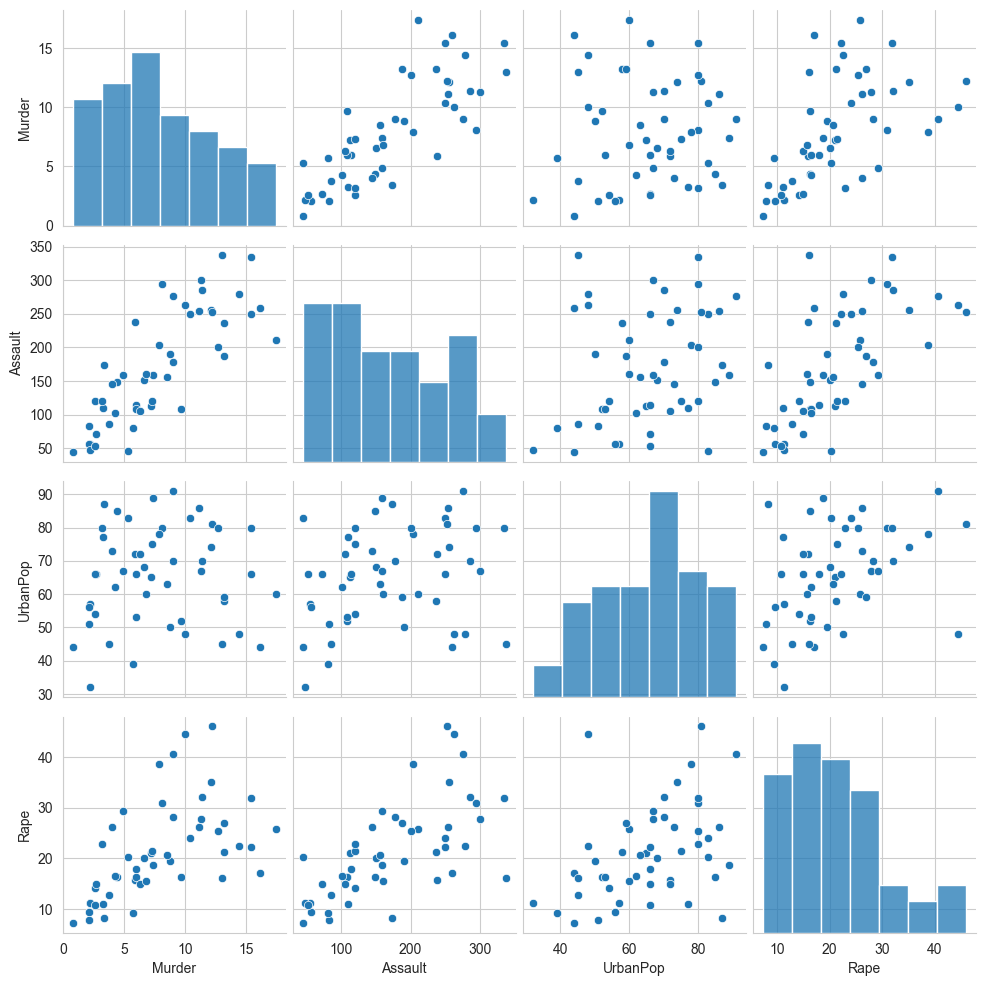

In [10]:
sns.pairplot(df)

plt.show()

# Figure 7 - Top Ten Murder Rates

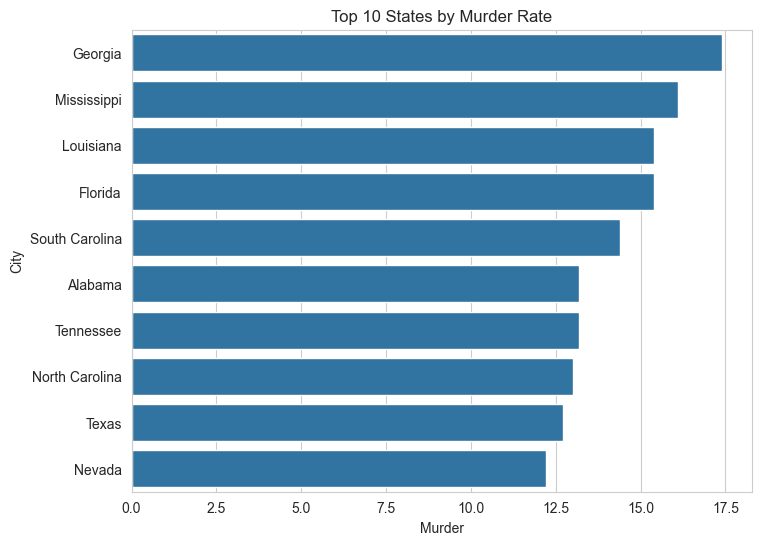

In [11]:
top = df.sort_values("Murder", ascending=False)

plt.figure(figsize=(8,6))

sns.barplot(
    data=top.head(10),
    y="City",
    x="Murder"
)

plt.title("Top 10 States by Murder Rate")

plt.show()

# Figure 8 - Top Ten Assault Rates

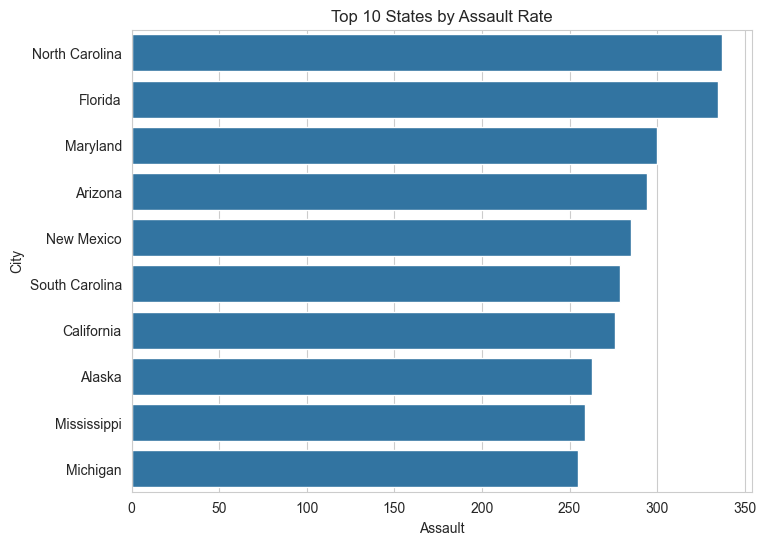

In [12]:
top = df.sort_values("Assault", ascending=False)

plt.figure(figsize=(8,6))

sns.barplot(
    data=top.head(10),
    y="City",
    x="Assault"
)

plt.title("Top 10 States by Assault Rate")

plt.show()

# Conclusion

This exploratory data analysis identified several important patterns within the US Arrests dataset.

A strong positive relationship exists between assault and murder rates, indicating that states experiencing higher levels of violent crime generally have elevated values across multiple crime categories.

Urban population showed only a weak association with violent crime, suggesting that urbanisation alone is not a reliable predictor of crime rates.

No missing values or duplicate records were identified, allowing the analysis to proceed without extensive data cleaning.

Overall, correlation analysis, scatterplots, boxplots, and ranking visualisations provided valuable insight into crime patterns across the United States.